In [2]:
import yaml
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
# --- Define Persona State ---
class PersonaState(TypedDict):
   persona: dict
   query: str
   response: str
# --- Load Persona Blueprint ---
with open("persona_blueprint.yaml", "r") as file:
    persona_config = yaml.safe_load(file)
# --- Nodes ---
def introduce_persona(state: PersonaState):
    agent = state["persona"]["agent"]
    print(f" Hello! I am {agent['name']}, your {agent['designation']}.")
    print(f"My purpose: {state['persona']['purpose']['description']}")
    return state
def execute_usecase(state: PersonaState):
    usecase = state["persona"]["use_case"]
    if usecase["domain"].lower() == "finance":
       state["response"] = "Based on your spending, I recommend diversifying into ETFs."
    else:
       state["response"] = "I can help analyze your data."
    print("Response:", state["response"])
    return state
# --- Build Graph ---
graph = StateGraph(PersonaState)
graph.add_node("introduce", introduce_persona)
graph.add_node("usecase", execute_usecase)
graph.add_edge(START, "introduce")
graph.add_edge("introduce", "usecase")
graph.add_edge("usecase", END)
app = graph.compile()
# --- Run ---
app.invoke({"persona": persona_config, "query": "What are the best saving options for 2025?"})


 Hello! I am FinBot, your Personal Finance Advisor.
My purpose: Assist customers with personalized investment and savings strategies.
Response: Based on your spending, I recommend diversifying into ETFs.


{'persona': {'agent': {'name': 'FinBot',
   'designation': 'Personal Finance Advisor'},
  'purpose': {'description': 'Assist customers with personalized investment and savings strategies.',
   'problem_statement': 'Users struggle to choose the right investment plans aligned with their risk profile.'},
  'use_case': {'domain': 'Finance',
   'type': 'Advisory',
   'scope': ['Provide investment recommendations',
    'Analyze spending patterns',
    'Generate savings reports']},
  'resources': {'data_sources': ['customer_financial_history_db',
    'market_trends_api'],
   'apis': ['https://api.stockmarket.com', 'https://api.banking.com'],
   'permissions': ['read:financial_data', 'write:advice_logs']},
  'interaction': {'human_interaction': {'mode': 'Chat-based',
    'tone': 'Professional and empathetic'},
   'collaboration': {'partners': ['RiskEvalAgent', 'PortfolioManagerAgent'],
    'communication_mode': 'Message passing via shared state'}},
  'metadata': {'version': '1.0',
   'author':

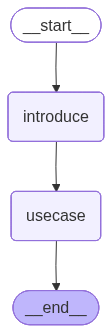

In [3]:
app